## Titanic Dataset Analysis

First, we need to load the dataset. Assuming the `titanic.csv` file is in your Colab environment or can be uploaded. If you don't have the dataset, you can download it from Kaggle or use a direct link like this:

```python
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
```

In [ ]:
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv



--2026-05-19 12:07:08--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.006s  

2026-05-19 12:07:09 (9.11 MB/s) - ‘titanic.csv’ saved [60302/60302]



In [ ]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('titanic.csv')
    print('Dataset loaded successfully.')
except FileNotFoundError:
    print('titanic.csv not found. Please ensure the file is uploaded or downloaded.')
    print('You can download it using: !wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
    # Optionally, you can try to download it here if you prefer a fully automated approach
    # !wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
    # df = pd.read_csv('titanic.csv')

Dataset loaded successfully.


### Initial Data Inspection

Let's look at the first few rows of the dataset to get a sense of its structure and the types of data it contains.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Business Insight from `.head()`:

This immediate view provides a snapshot of our data. We can see various features like `PassengerId`, `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, and `Embarked`. The `Survived` column (0=No, 1=Yes) is our target variable. We can immediately identify categorical data (`Sex`, `Embarked`, `Pclass`) and numerical data (`Age`, `Fare`, `SibSp`, `Parch`). The `Name` and `Ticket` columns appear to be unique identifiers or strings, while `Cabin` might have many missing values, which will need to be addressed.

Next, let's get a concise summary of the DataFrame, including the data types of each column and the number of non-null values. This is crucial for identifying missing data and planning data cleaning steps.

In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Business Insight from `.info()`:

The `.info()` output is highly valuable. It tells us:

*   **Missing Values**: `Age`, `Cabin`, and `Embarked` have missing values. `Cabin` has a significant number of missing values (only 204 non-null out of 891), suggesting it might not be a reliable feature or requires careful imputation/feature engineering. `Age` is also critical for survival analysis, so its missing values need handling. `Embarked` has only 2 missing values, which is minor.
*   **Data Types**: Most columns are of appropriate types (e.g., `int64` for `Survived`, `Pclass`, `Age` and `float64` for `Fare`). `Sex`, `Embarked`, `Name`, `Ticket`, and `Cabin` are `object` type, indicating they are strings or mixed types, which is expected for categorical or text data. This helps us plan for encoding categorical features if needed.
*   **Memory Usage**: The memory usage provides an idea of the dataset size.

This insight immediately highlights data quality issues, particularly concerning missing data in key columns, that need to be addressed before any meaningful analysis can be performed.

Finally, let's generate descriptive statistics for numerical columns to understand their distribution, central tendency, and spread.

In [ ]:
# Generate descriptive statistics for numerical columns
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Business Insight from `.describe()`:

*   **Age Distribution**: The average age is around 29.7 years, with a standard deviation of 14.5. The minimum age is 0.42 (a baby), and the maximum is 80. The 25th, 50th (median), and 75th percentiles give us a good sense of the age spread. This indicates a diverse age range among passengers.
*   **Fare Distribution**: The average fare is about 32.2. However, the maximum fare is 512.33, and the 75th percentile is only 31, suggesting a highly skewed distribution with some very expensive tickets. This could imply a strong correlation between fare and passenger class or wealth.
*   **Survival Rate (indirectly)**: The mean of `Survived` is 0.3838, which means approximately 38.4% of the passengers in this dataset survived. This is a crucial overall survival rate benchmark.
*   **Passenger Class (`Pclass`)**: The mean `Pclass` is 2.3, suggesting a higher concentration of passengers in 2nd and 3rd class compared to 1st class.
*   **Siblings/Spouses (`SibSp`) and Parents/Children (`Parch`)**: These indicate family relationships. The maximum values (8 for SibSp and 6 for Parch) suggest some large families, but the means are low, indicating most people traveled alone or in small groups.

This descriptive summary gives us foundational insights into the passenger demographics and ticket costs, which are critical for understanding factors influencing survival.

### Missing Value Analysis

Identifying and understanding missing values is a crucial step in data preprocessing. We'll calculate the percentage of missing values for each column to prioritize our imputation strategies.

In [ ]:
# Calculate the percentage of missing values for each column
missing_data = df.isnull().sum() / len(df) * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
display(missing_data)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467


#### Business Insight from Missing Value Analysis:

*   **`Cabin` (77.1% missing)**: This column has a very high percentage of missing values. It's likely not feasible to accurately impute such a large proportion of missing data. We might consider dropping this column or creating a new feature indicating whether cabin information is present (`HasCabin`).
*   **`Age` (19.9% missing)**: Around 20% of age data is missing. Age is a significant factor in survival, so imputing these values is important. Common strategies include imputing with the mean, median, or using more sophisticated methods like regression or K-Nearest Neighbors (KNN).
*   **`Embarked` (0.22% missing)**: Only 2 values are missing for 'Embarked'. This is a minor issue and can be easily handled by imputing with the mode (most frequent embarkation port) or simply dropping the few rows if the dataset is large enough.

### Survival Rate

Let's calculate the overall survival rate of the passengers to get a baseline understanding.

In [ ]:
# Calculate overall survival rate
overall_survival_rate = df['Survived'].mean() * 100
print(f"Overall Survival Rate: {overall_survival_rate:.2f}%")

Overall Survival Rate: 38.38%


#### Business Insight from Overall Survival Rate:

Approximately 38.4% of the passengers survived the Titanic disaster. This low survival rate highlights the severity of the event. This serves as our baseline. Any further analysis on factors affecting survival (gender, class, age) will aim to explain variations from this overall rate, which is crucial for understanding who was prioritized or had better chances of survival.

### Male vs Female Survival

Gender is often a critical factor in historical disasters due to 'women and children first' policies. Let's analyze the survival rates based on gender.

In [ ]:
# Calculate survival rate by gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
display(gender_survival)

,Survived
Sex,
female,74.203822
male,18.890815


#### Business Insight from Male vs Female Survival:

This analysis strongly supports the 'women and children first' convention. Women had a significantly higher survival rate (around 74.2%) compared to men (around 18.9%). This insight is critical for understanding the social dynamics and rescue priorities during the disaster, suggesting that gender played a primary role in survival chances. This feature is likely a very strong predictor in any survival model.

### Age Distribution

Understanding the age distribution of passengers can reveal demographic characteristics and how age might correlate with other factors like survival.

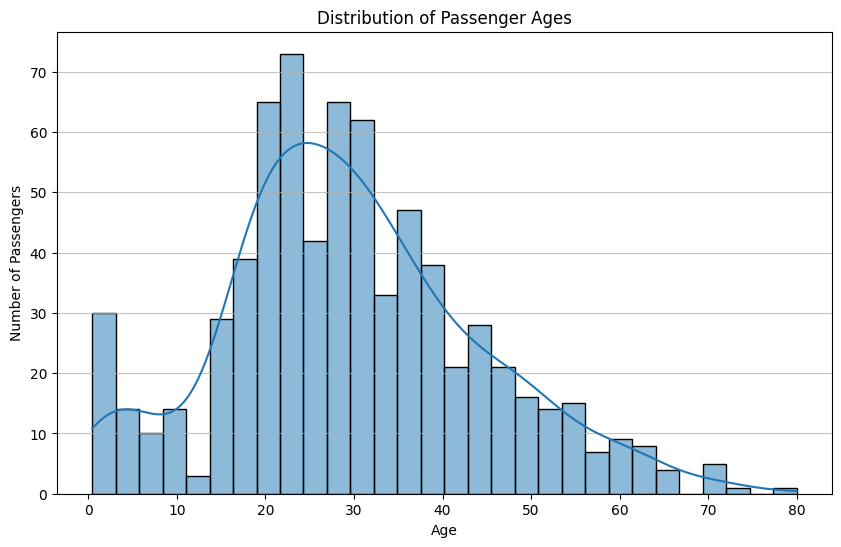

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of age
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Business Insight from Age Distribution:

The histogram shows a distribution of passenger ages. We can observe a high concentration of young adults (20-40 years old), a significant number of children (under 10), and fewer elderly passengers. This distribution is typical for a large vessel. The presence of many young adults suggests a working or traveling population, while the children highlight the family aspect of the journey. Understanding this distribution is important for segmenting passengers and analyzing how different age groups might have been affected by the disaster or rescue efforts (e.g., specific protocols for children or the elderly).

### Passenger Class Distribution

Passenger class (`Pclass`) is often indicative of socio-economic status and potentially the location on the ship, both of which could influence survival chances. Let's examine its distribution.

/tmp/ipykernel_592/3971697297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='viridis')


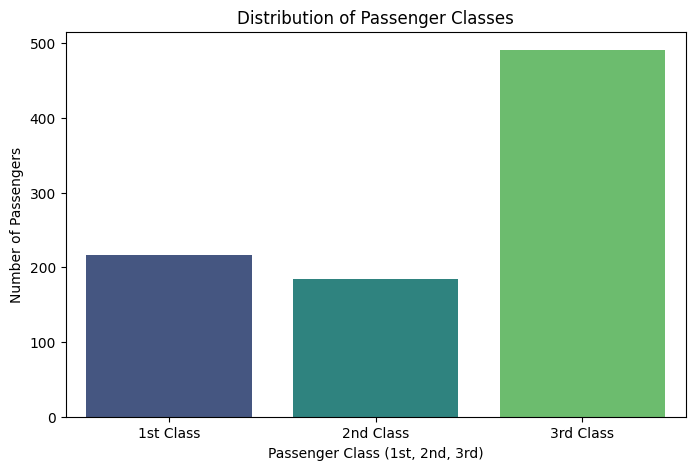

In [ ]:
# Calculate and plot passenger class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', data=df, palette='viridis')
plt.title('Distribution of Passenger Classes')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.show()

#### Business Insight from Passenger Class Distribution:

This plot clearly shows that the majority of passengers were in 3rd class, followed by 1st class, and then 2nd class. This skewed distribution means that a larger proportion of the passenger manifest comprises those in lower economic classes. This is a critical insight because passenger class is very likely correlated with factors such as cabin location, access to lifeboats, and overall treatment during the disaster. It sets the stage for investigating if socio-economic status, as represented by `Pclass`, played a role in survival rates.

### Survival Count Bar Chart

To visually summarize the number of survivors versus non-survivors, a bar chart is an effective tool.

/tmp/ipykernel_592/583648694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


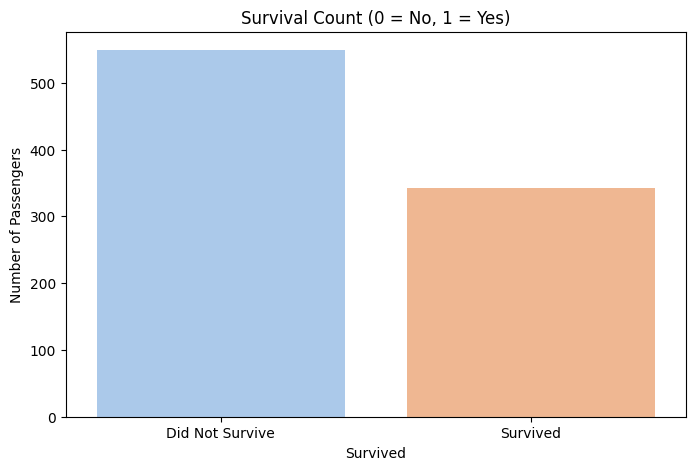

In [ ]:
# Plot survival count bar chart
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

#### Business Insight from Survival Count Bar Chart:

The bar chart visually reinforces the overall survival rate observation: significantly more passengers did not survive than did. This direct comparison highlights the tragic scale of the disaster. From a business perspective (e.g., if this were a study for safety regulations), this plot immediately emphasizes the need for improved safety protocols, evacuation procedures, and ship design to prevent such a high casualty rate in future incidents. It underscores the severity of the event and the need to investigate the underlying factors contributing to non-survival.